<a href="https://colab.research.google.com/github/siddhartha-sai-17/Transformer/blob/main/BERT(Resume_Dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")

print("Path to dataset files:", path)

100%|██████████| 62.5M/62.5M [00:00<00:00, 138MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/snehaanbhawal/resume-dataset/versions/1


In [ ]:
import os
print(os.listdir(path))

['data', 'Resume']


In [ ]:
import pandas as pd
df = pd.read_csv(f'{path}/Resume/Resume.csv')
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
print(df.shape)

print(df.columns)

df.head()

(2484, 4)
Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
df.isnull().sum()

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


In [ ]:
import re

def remove_urls(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', str(text))

In [ ]:
def remove_special_chars(text):
    return re.sub(r'[^a-zA-Z\s]', ' ', text)

In [ ]:
def to_lower(text):
    return text.lower()

In [ ]:
def remove_extra_spaces(text):
    return re.sub(r'\s+', ' ', text).strip()

In [ ]:
def clean_resume(text):

    text = remove_urls(text)

    text = remove_special_chars(text)

    text = to_lower(text)

    text = remove_extra_spaces(text)

    return text

In [ ]:
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


In [ ]:
print("Original Resume:\n")
print(df['Resume_str'].iloc[0][:500])

print("\n\nCleaned Resume:\n")
print(df['clean_resume'].iloc[0][:500])

Original Resume:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-task


Cleaned Resume:

hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relati

In [ ]:
import re

# Remove URLs
def remove_urls(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', str(text))

# Remove special characters
def remove_special_chars(text):
    return re.sub(r'[^a-zA-Z\s]', ' ', text)

# Convert to lowercase
def to_lower(text):
    return text.lower()

# Remove extra spaces
def remove_extra_spaces(text):
    return re.sub(r'\s+', ' ', text).strip()

# Complete cleaning pipeline
def clean_resume(text):

    text = remove_urls(text)

    text = remove_special_chars(text)

    text = to_lower(text)

    text = remove_extra_spaces(text)

    return text

# Apply preprocessing
df['clean_resume'] = df['Resume_str'].apply(clean_resume)

print(df[['Category', 'clean_resume']].head())

  Category                                       clean_resume
0       HR  hr administrator marketing associate hr admini...
1       HR  hr specialist us hr operations summary versati...
2       HR  hr director summary over years experience in r...
3       HR  hr specialist summary dedicated driven and dyn...
4       HR  hr manager skill highlights hr skills hr depar...


In [ ]:
print("Original Resume:\n")
print(df['Resume_str'].iloc[0][:500])

print("\n\nCleaned Resume:\n")
print(df['clean_resume'].iloc[0][:500])

Original Resume:

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  Team management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-task


Cleaned Resume:

hr administrator marketing associate hr administrator summary dedicated customer service manager with years of experience in hospitality and customer service management respected builder and leader of customer focused teams strives to instill a shared enthusiastic commitment to customer service highlights focused on customer satisfaction team management marketing savvy conflict resolution techniques training and development skilled multi tasker client relati

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(df['Category'])

print("Number of Categories:", len(label_encoder.classes_))
print(label_encoder.classes_)

Number of Categories: 24
['ACCOUNTANT' 'ADVOCATE' 'AGRICULTURE' 'APPAREL' 'ARTS' 'AUTOMOBILE'
 'AVIATION' 'BANKING' 'BPO' 'BUSINESS-DEVELOPMENT' 'CHEF' 'CONSTRUCTION'
 'CONSULTANT' 'DESIGNER' 'DIGITAL-MEDIA' 'ENGINEERING' 'FINANCE' 'FITNESS'
 'HEALTHCARE' 'HR' 'INFORMATION-TECHNOLOGY' 'PUBLIC-RELATIONS' 'SALES'
 'TEACHER']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['clean_resume'],
    df['label'],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 1987
Testing Samples : 497


In [ ]:
print(df[['Category', 'label', 'clean_resume']].head())

  Category  label                                       clean_resume
0       HR     19  hr administrator marketing associate hr admini...
1       HR     19  hr specialist us hr operations summary versati...
2       HR     19  hr director summary over years experience in r...
3       HR     19  hr specialist summary dedicated driven and dyn...
4       HR     19  hr manager skill highlights hr skills hr depar...


In [ ]:
!pip install transformers -q

In [ ]:
from transformers import BertTokenizer

In [ ]:
tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
sample_resume = X_train.iloc[0]

print(sample_resume[:500])

hr coordinator summary from my first job as a retail salesperson i had a passion for leadership and the development of others as a human resources professional i have had the privilege of working with new staff members to help them be successful in the organization my human resources experience is comprised of generalist responsibilities where i have been able to contribute to the betterment of the organization and play a key role in increasing retention for my employer highlights hr policies an


In [ ]:
tokens = tokenizer.tokenize(sample_resume)

print(tokens[:50])

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (778 > 512). Running this sequence through the model will result in indexing errors


['hr', 'coordinator', 'summary', 'from', 'my', 'first', 'job', 'as', 'a', 'retail', 'sales', '##person', 'i', 'had', 'a', 'passion', 'for', 'leadership', 'and', 'the', 'development', 'of', 'others', 'as', 'a', 'human', 'resources', 'professional', 'i', 'have', 'had', 'the', 'privilege', 'of', 'working', 'with', 'new', 'staff', 'members', 'to', 'help', 'them', 'be', 'successful', 'in', 'the', 'organization', 'my', 'human', 'resources']


In [ ]:
tokens_with_special = ['[CLS]'] + tokens + ['[SEP]']

print(tokens_with_special[:30])

['[CLS]', 'hr', 'coordinator', 'summary', 'from', 'my', 'first', 'job', 'as', 'a', 'retail', 'sales', '##person', 'i', 'had', 'a', 'passion', 'for', 'leadership', 'and', 'the', 'development', 'of', 'others', 'as', 'a', 'human', 'resources', 'professional', 'i']


In [ ]:
token_ids = tokenizer.convert_tokens_to_ids(
    tokens_with_special
)

print(token_ids[:30])

[101, 17850, 10669, 12654, 2013, 2026, 2034, 3105, 2004, 1037, 7027, 4341, 27576, 1045, 2018, 1037, 6896, 2005, 4105, 1998, 1996, 2458, 1997, 2500, 2004, 1037, 2529, 4219, 2658, 1045]


In [ ]:
encoded = tokenizer(
    sample_resume,
    add_special_tokens=True,
    max_length=128,
    padding="max_length",
    truncation=True,
    return_attention_mask=True
)

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

sample_resume = X_train.iloc[0]

encoded = tokenizer(
    sample_resume,
    add_special_tokens=True,
    max_length=128,
    padding="max_length",
    truncation=True,
    return_attention_mask=True
)

print(encoded.keys())

KeysView({'input_ids': [101, 17850, 10669, 12654, 2013, 2026, 2034, 3105, 2004, 1037, 7027, 4341, 27576, 1045, 2018, 1037, 6896, 2005, 4105, 1998, 1996, 2458, 1997, 2500, 2004, 1037, 2529, 4219, 2658, 1045, 2031, 2018, 1996, 14293, 1997, 2551, 2007, 2047, 3095, 2372, 2000, 2393, 2068, 2022, 3144, 1999, 1996, 3029, 2026, 2529, 4219, 3325, 2003, 11539, 1997, 2236, 2923, 10198, 2073, 1045, 2031, 2042, 2583, 2000, 9002, 2000, 1996, 2488, 3672, 1997, 1996, 3029, 1998, 2377, 1037, 3145, 2535, 1999, 4852, 20125, 2005, 2026, 11194, 11637, 17850, 6043, 1998, 8853, 11532, 7904, 14812, 2458, 3095, 2731, 1998, 2458, 2047, 7904, 2006, 9405, 2125, 9405, 6107, 2375, 3716, 26854, 11532, 6666, 8911, 4114, 9319, 18777, 3012, 7513, 2436, 7621, 17571, 7065, 16613, 2098, 1996, 10296, 2832, 2005, 2035, 2047, 28208, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

bert_model = BertModel.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
sample_resume = X_train.iloc[0]

print(sample_resume[:300])

hr coordinator summary from my first job as a retail salesperson i had a passion for leadership and the development of others as a human resources professional i have had the privilege of working with new staff members to help them be successful in the organization my human resources experience is c


In [ ]:
encoded = tokenizer(
    sample_resume,
    max_length=64,
    padding="max_length",
    truncation=True,
    return_tensors="pt"
)

In [ ]:
input_ids = encoded["input_ids"]
token_type_ids = encoded["token_type_ids"]

print(input_ids.shape)
print(token_type_ids.shape)

torch.Size([1, 64])
torch.Size([1, 64])


In [ ]:
token_embeddings = bert_model.embeddings.word_embeddings(
    input_ids
)

print(token_embeddings.shape)

torch.Size([1, 64, 768])


In [ ]:
import torch

position_ids = torch.arange(
    input_ids.size(1)
).unsqueeze(0)

position_embeddings = (
    bert_model.embeddings.position_embeddings(
        position_ids
    )
)

print(position_embeddings.shape)

torch.Size([1, 64, 768])


In [ ]:
segment_embeddings = (
    bert_model.embeddings.token_type_embeddings(
        token_type_ids
    )
)

print(segment_embeddings.shape)

torch.Size([1, 64, 768])


In [ ]:
final_embedding = (
    token_embeddings
    + position_embeddings
    + segment_embeddings
)

print(final_embedding.shape)

torch.Size([1, 64, 768])


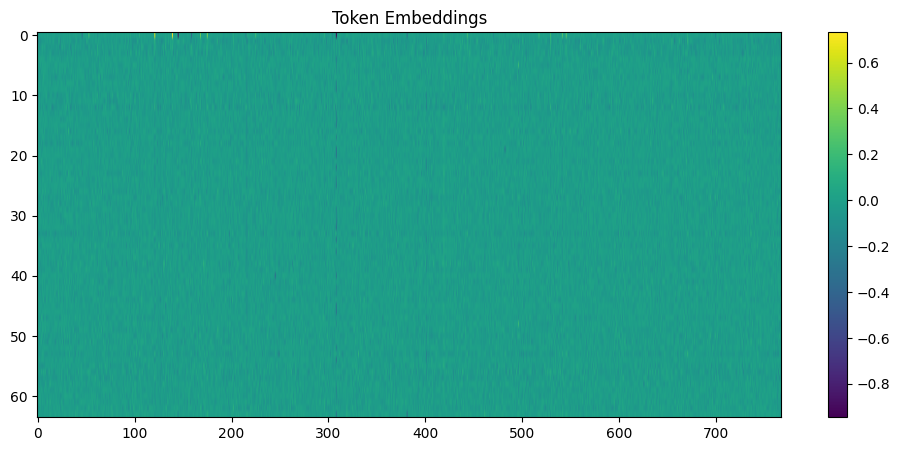

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.imshow(
    token_embeddings[0].detach().numpy(),
    aspect="auto"
)

plt.title("Token Embeddings")

plt.colorbar()

plt.show()

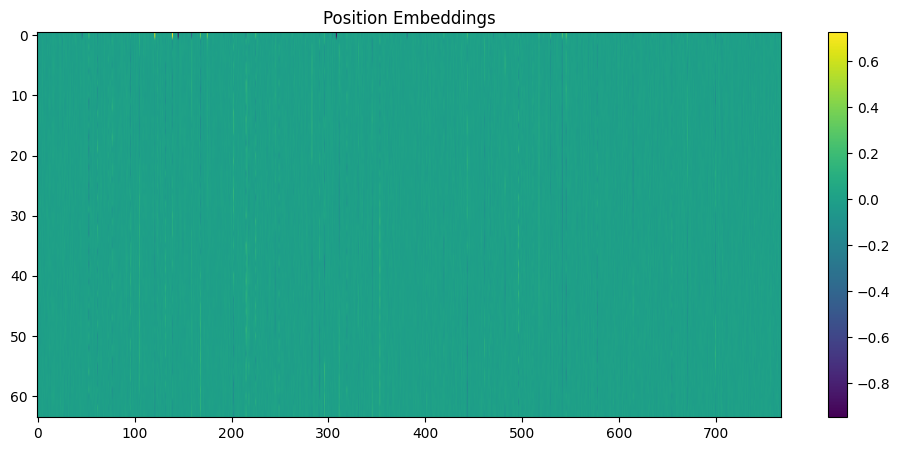

In [ ]:
plt.figure(figsize=(12,5))

plt.imshow(
    position_embeddings[0].detach().numpy(),
    aspect="auto"
)

plt.title("Position Embeddings")

plt.colorbar()

plt.show()

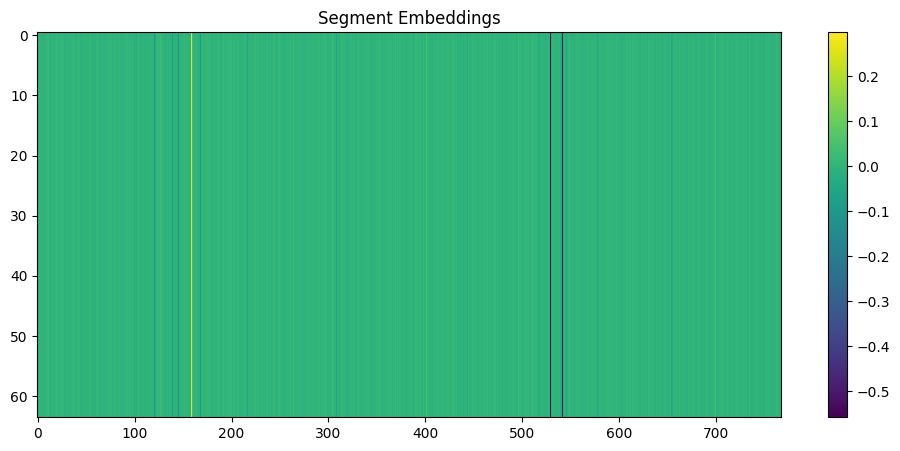

In [ ]:
plt.figure(figsize=(12,5))

plt.imshow(
    segment_embeddings[0].detach().numpy(),
    aspect="auto"
)

plt.title("Segment Embeddings")

plt.colorbar()

plt.show()

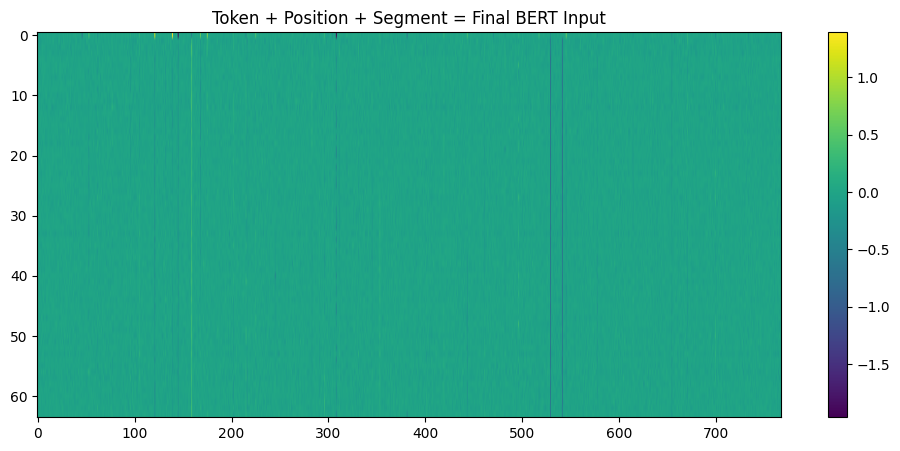

In [ ]:
plt.figure(figsize=(12,5))

plt.imshow(
    final_embedding[0].detach().numpy(),
    aspect="auto"
)

plt.title(
    "Token + Position + Segment = Final BERT Input"
)

plt.colorbar()

plt.show()

In [ ]:
sentence = "experienced python developer"

In [ ]:
tokens = tokenizer.tokenize(sentence)

tokens = ['[CLS]'] + tokens + ['[SEP]']

print(tokens)

['[CLS]', 'experienced', 'python', 'developer', '[SEP]']


In [ ]:
positions = list(range(len(tokens)))

print(positions)

[0, 1, 2, 3, 4]


In [ ]:
import pandas as pd

position_df = pd.DataFrame({
    "Word": tokens,
    "Position": positions
})

position_df

,Word,Position
0,[CLS],0
1,experienced,1
2,python,2
3,developer,3
4,[SEP],4


In [ ]:
import torch

position_ids = torch.tensor(
    [positions]
)

position_embeddings = (
    bert_model.embeddings.position_embeddings(
        position_ids
    )
)

In [ ]:
print(position_embeddings.shape)

torch.Size([1, 5, 768])


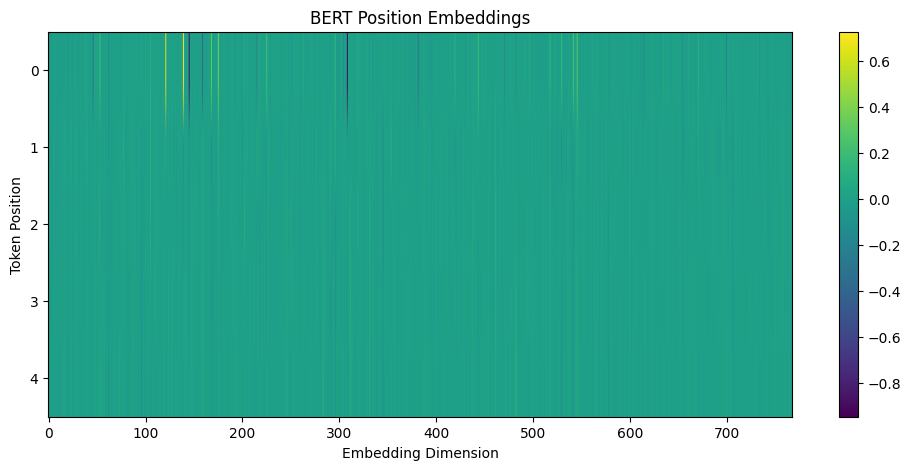

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.imshow(
    position_embeddings[0].detach().numpy(),
    aspect='auto'
)

plt.title("BERT Position Embeddings")

plt.xlabel("Embedding Dimension")

plt.ylabel("Token Position")

plt.colorbar()

plt.show()

In [ ]:
for i, token in enumerate(tokens):

    print(
        f"{token:15s} Position: {i}"
    )

[CLS]           Position: 0
experienced     Position: 1
python          Position: 2
developer       Position: 3
[SEP]           Position: 4


In [ ]:
sentence_a = "I know Python"

sentence_b = "I know TensorFlow"

In [ ]:
encoded = tokenizer(
    sentence_a,
    sentence_b,
    return_tensors="pt"
)

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(
    encoded["input_ids"][0]
)

print(tokens)

['[CLS]', 'i', 'know', 'python', '[SEP]', 'i', 'know', 'tensor', '##flow', '[SEP]']


In [ ]:
segment_ids = encoded["token_type_ids"][0]

print(segment_ids)

tensor([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])


In [ ]:
import pandas as pd

segment_df = pd.DataFrame({
    "Token": tokens,
    "Segment_ID": segment_ids.numpy()
})

segment_df

,Token,Segment_ID
0,[CLS],0
1,i,0
2,know,0
3,python,0
4,[SEP],0
5,i,1
6,know,1
7,tensor,1
8,##flow,1
9,[SEP],1


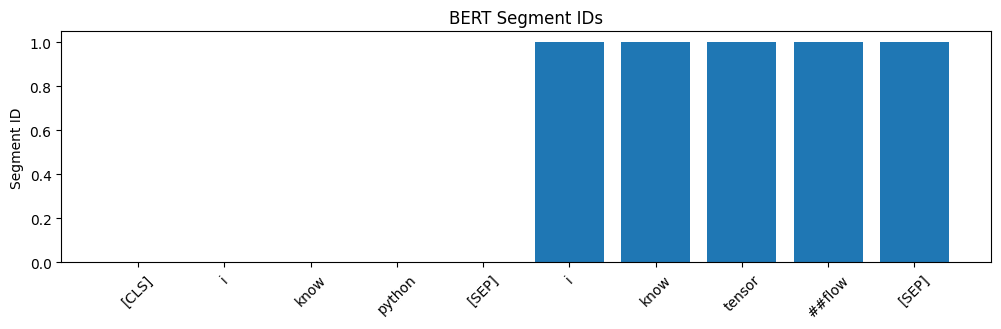

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,3))

plt.bar(
    range(len(segment_ids)),
    segment_ids.numpy()
)

plt.xticks(
    range(len(tokens)),
    tokens,
    rotation=45
)

plt.ylabel("Segment ID")

plt.title("BERT Segment IDs")

plt.show()

In [ ]:
segment_embeddings = (
    bert_model.embeddings.token_type_embeddings(
        encoded["token_type_ids"]
    )
)

In [ ]:
print(segment_embeddings.shape)

torch.Size([1, 10, 768])


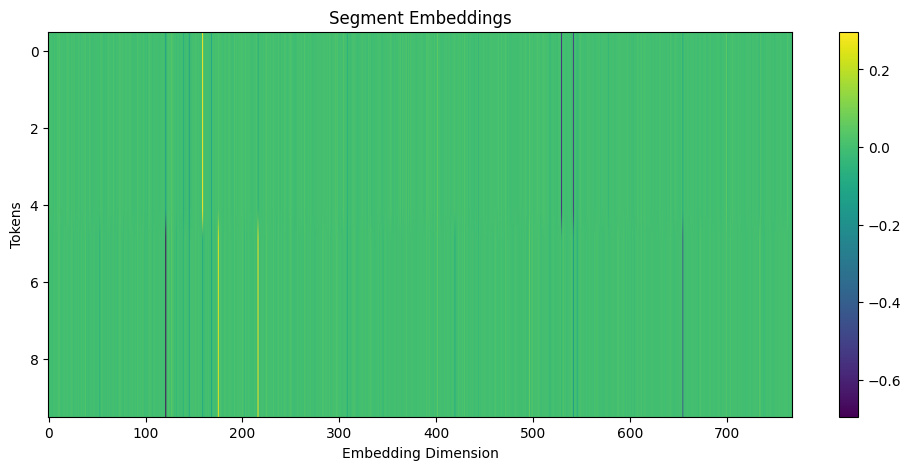

In [ ]:
plt.figure(figsize=(12,5))

plt.imshow(
    segment_embeddings[0].detach().numpy(),
    aspect="auto"
)

plt.title("Segment Embeddings")

plt.xlabel("Embedding Dimension")

plt.ylabel("Tokens")

plt.colorbar()

plt.show()

In [ ]:
import numpy as np

tokens = ['developer', 'python', 'machine', 'learning']

embedding_dim = 8

embeddings = np.random.rand(
    len(tokens),
    embedding_dim
)

print(embeddings.shape)

(4, 8)


In [ ]:
WQ = np.random.rand(8,8)
WK = np.random.rand(8,8)
WV = np.random.rand(8,8)

Q = embeddings @ WQ
K = embeddings @ WK
V = embeddings @ WV


In [ ]:
WQ = np.random.rand(8,8)
WK = np.random.rand(8,8)
WV = np.random.rand(8,8)

Q = embeddings @ WQ
K = embeddings @ WK
V = embeddings @ WV

In [ ]:
scores = Q @ K.T

print(scores.shape)

(4, 4)


In [ ]:
dk = K.shape[-1]

scaled_scores = scores / np.sqrt(dk)

In [ ]:
def softmax(x):
    exp_x = np.exp(x - np.max(x))
    return exp_x / exp_x.sum(axis=-1, keepdims=True)

attention_weights = softmax(
    scaled_scores
)

print(attention_weights)

[[1.33315833e-03 8.35188973e-03 6.93134189e-01 2.97180763e-01]
 [1.51032766e-04 1.69099527e-03 7.64955004e-01 2.33202968e-01]
 [1.32077669e-07 1.13501856e-05 8.96036540e-01 1.03951978e-01]
 [3.88731249e-07 2.49031665e-05 8.81250768e-01 1.18723941e-01]]


In [ ]:
attention_output = attention_weights @ V

print(attention_output.shape)

(4, 8)


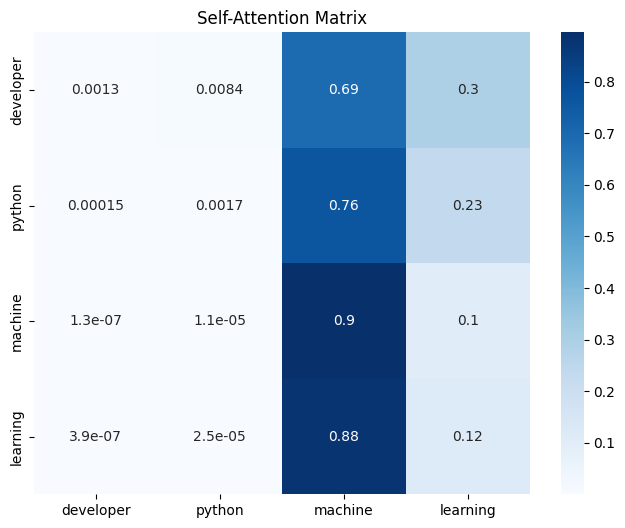

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    attention_weights,
    annot=True,
    xticklabels=tokens,
    yticklabels=tokens,
    cmap='Blues'
)

plt.title("Self-Attention Matrix")

plt.show()

In [ ]:
num_heads = 4

head_outputs = []

for _ in range(num_heads):

    WQ = np.random.rand(8,8)
    WK = np.random.rand(8,8)
    WV = np.random.rand(8,8)

    Q = embeddings @ WQ
    K = embeddings @ WK
    V = embeddings @ WV

    scores = Q @ K.T

    scaled = scores / np.sqrt(8)

    weights = softmax(scaled)

    output = weights @ V

    head_outputs.append(output)

In [ ]:
multi_head_output = np.concatenate(
    head_outputs,
    axis=-1
)

print(multi_head_output.shape)

(4, 32)


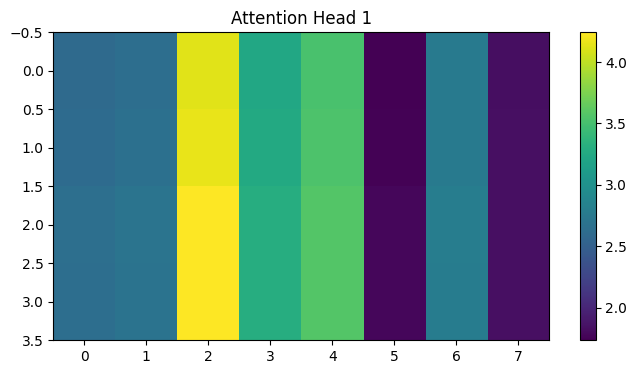

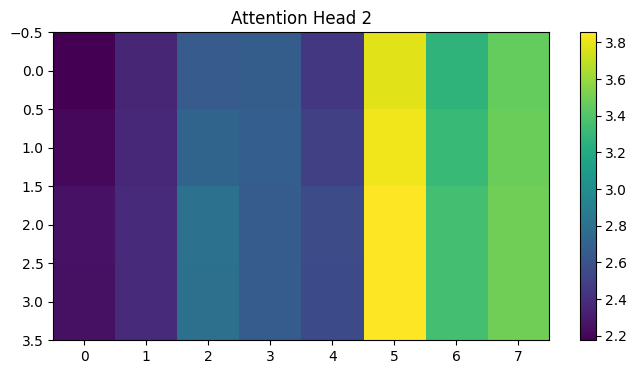

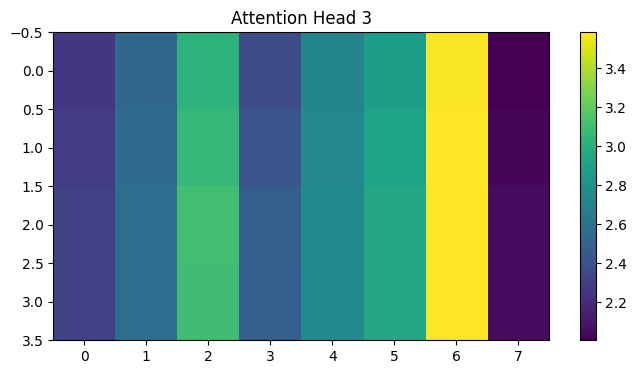

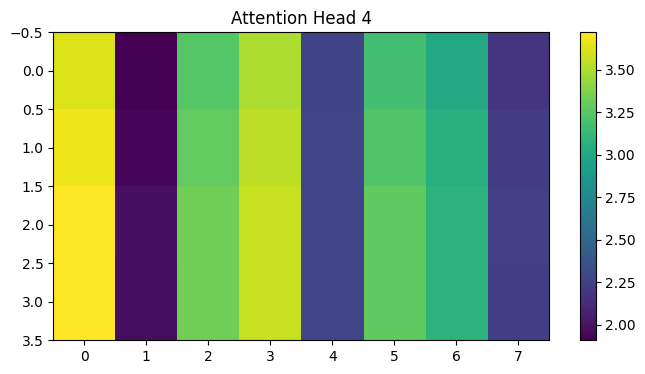

In [ ]:
for i, head in enumerate(head_outputs):

    plt.figure(figsize=(8,4))

    plt.imshow(head, aspect='auto')

    plt.title(f'Attention Head {i+1}')

    plt.colorbar()

    plt.show()

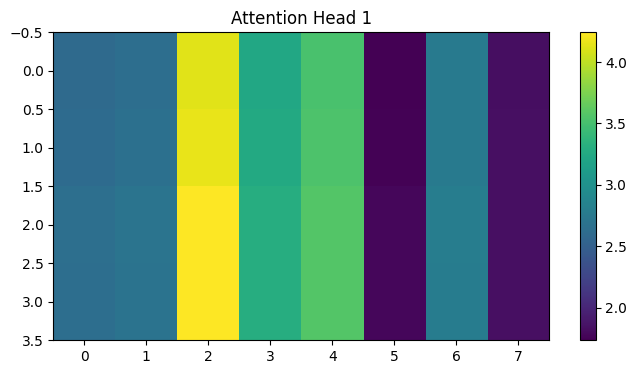

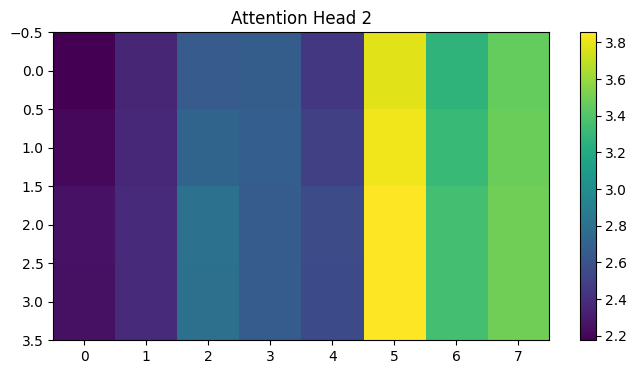

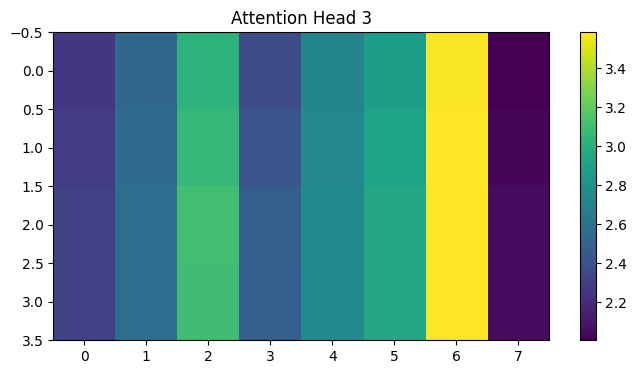

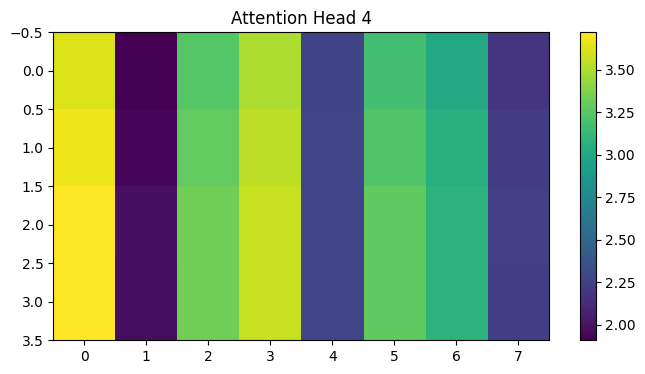

In [ ]:
for i, head in enumerate(head_outputs):

    plt.figure(figsize=(8,4))

    plt.imshow(head, aspect='auto')

    plt.title(f'Attention Head {i+1}')

    plt.colorbar()

    plt.show()

In [ ]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

MAX_LEN = 256

train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=MAX_LEN
)

In [ ]:
import torch
from torch.utils.data import Dataset

In [ ]:
class ResumeDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels.iloc[idx],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = ResumeDataset(
    train_encodings,
    y_train
)

test_dataset = ResumeDataset(
    test_encodings,
    y_test
)

In [ ]:
print("Training Samples:", len(train_dataset))
print("Testing Samples:", len(test_dataset))

Training Samples: 1987
Testing Samples: 497


In [ ]:
sample = train_dataset[0]

print(sample.keys())

dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'labels'])


In [ ]:
print(sample['input_ids'].shape)

print(sample['attention_mask'].shape)

print(sample['labels'])

torch.Size([256])
torch.Size([256])
tensor(19)


In [ ]:
from transformers import BertForSequenceClassification

In [ ]:
num_classes = len(label_encoder.classes_)

print("Number of Classes:", num_classes)

Number of Classes: 24


In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_classes
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=num_classes
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=2,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    eval_strategy="epoch",

    save_strategy="epoch",

    logging_steps=50,

    report_to="none"
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
